# `gwtf` global-fit mode: per-walker data and PSD

This notebook demonstrates the `gf_mode` ("global-fit mode") option of `AnalyticTimeFrequencyWaveform`.

Each walker is given its own copy of the PSD and data arrays to mimic what is done in the global fit. This is exactly what `gf_mode=True` provides:

- In the **default** mode, `channels` (the data) and `psds` have shape `(nT, nF, n_channels)` and are *shared* across all sources in a batch.
- In **global-fit mode**, they gain a leading walker axis: `(nwalkers, nT, nF, n_channels)`. Walker `w` computes its inner products $\langle d_w \mid h_w \rangle$ and $\langle h_w \mid h_w \rangle$ against *its own* slice `channels[w]` / `psds[w]`.

We work directly with the TDI (AET) channels throughout. To keep the example self-contained we simply **duplicate one dataset and PSD across all the walker arrays** — in a real global fit each walker's data slice would differ (e.g. residuals after subtracting the other source types).

> **Note:** `gf_mode` is intended for the ordinary per-segment statistic kernels (returning $\langle d\mid h\rangle$, $\langle h\mid h\rangle$ per time segment). It is not intended for the semi-coherent search kernels (`N_seg`).

In [18]:
import matplotlib.pyplot as plt
import numpy as np

from pygwtf.generator import AnalyticTimeFrequencyWaveform
from pygwtf.models import TaylorT2Ecc

The time-frequency grid is set up exactly as in the quickstart.

In [19]:
# Define the parameters for the time-frequency grid
dT = 86400 / 4  # 6 hours # SFT time.
nT = 365 * 4  # 1 year # Number of SFT time bins in the total observation
dt = 5  # time step for the *time-domain* data -> used to determine fmax for the SFT
dF = 1 / dT  # Frequency spacing within the SFT.
# 1/(2*dt) is the Nyquist frequency for the time-domain data
fmax = 1 / (2 * dt)  # Nyquist frequency for the time-domain data

nF = int((fmax) / dF) + 1  # Number of frequency bins needed to cover the Nyquist frequency.

config = {
    "dT": dT,
    "nT": nT,
    "dt": dt,
    "dF": dF,
    "nF": nF,
    "kernel_width": 10,  # Number of frequency bins to use in the fresnel kernel
}

## Build a TDI dataset

We first build a single time-frequency dataset to serve as the "observed data", using the TDI (AET) channels (`tdi_type=2`, so `n_channels = 3`). The data is the superposition of a couple of injected signals. Since we are using TDI we also pass response/extrinsic parameters `[cosi, pol, ecliptic_long, ecliptic_lat]` — one row per injected source.

In [20]:
# Generator used purely to synthesise the injected TDI data (default, non-gf mode).
data_generator = AnalyticTimeFrequencyWaveform(
    model_class=TaylorT2Ecc,
    config=config,
    tdi_type=2,
)

# A couple of injected sources whose superposition forms the data.
injection_pars = {
    "M": np.array([30.0, 42.0]),
    "eta": np.array([0.25, 0.20]),
    "cosi": np.array([0.5, 0.2]),
    "e0": np.array([1e-3, 2e-3]),
    "D": np.array([1e3, 1e3]),
    "f0": np.array([4e-2, 2.5e-2]),
    "phi_coal": np.array([0.1, 0.7]),
}

# Response/extrinsic parameters [cosi, pol, ecliptic_long, ecliptic_lat], one row per source.
injection_response = np.array(
    [
        [injection_pars["cosi"][0], np.pi / 6, 5 * np.pi / 4, np.pi / 3],
        [injection_pars["cosi"][1], np.pi / 5, np.pi, np.pi / 4],
    ]
)

# Sum the injected signals over sources -> the (nT, nF, 3) AET data array.
signal = data_generator(injection_pars, parameters_response=injection_response).sum(0)

# Flat PSD on the AET channels.
PSD_LEVEL = 1e-34
psd = np.ones_like(signal.real) * PSD_LEVEL

print("data shape:", signal.shape, "| psd shape:", psd.shape)

Spacecraft orbits not supplied. Falling back to analytic orbits
Spacecraft light travel times not supplied. Falling back to analytic calculation
data shape: (1460, 2161, 3) | psd shape: (1460, 2161, 3)


## Set up the walkers

Now suppose a global fit is running `nwalkers` walkers. Each walker holds:

1. a set of parameters **parameter** (one source per walker here)
2. its **own copy of the data and PSD arrays**.

We build the per-walker parameter proposals by scattering around one of the injected sources, and we build the per-walker data/PSD by **duplicating the single dataset above across the walker axis**. The resulting `channels` / `psds` arrays therefore have shape `(nwalkers, nT, nF, n_channels)`.

In [30]:
nwalkers = 30
rng = np.random.default_rng(1729)

# One parameter proposal per walker, scattered around the first injected source.
walker_pars = {
    "M": rng.uniform(28, 32, size=nwalkers),
    "eta": rng.uniform(0.24, 0.25, size=nwalkers),
    "cosi": rng.uniform(0.45, 0.55, size=nwalkers),
    "e0": rng.uniform(0.8e-3, 1.2e-3, size=nwalkers),
    "D": np.full(nwalkers, 1e3),
    "f0": rng.uniform(3.9e-2, 4.1e-2, size=nwalkers),
    "phi_coal": rng.uniform(0.0, 0.2, size=nwalkers),
}

# Response parameters, one row per walker (scattered around the first injection here).
walker_response = np.column_stack(
    [
        walker_pars["cosi"],
        np.full(nwalkers, np.pi / 6),
        np.full(nwalkers, 5 * np.pi / 4),
        np.full(nwalkers, np.pi / 3),
    ]
)

# Duplicate the single dataset / PSD across all walkers -> (nwalkers, nT, nF, n_channels).

channels_gf = np.array([signal]*30).copy()
psds_gf = np.array([psd]*30).copy()

print("channels_gf shape:", channels_gf.shape)
print("psds_gf shape:    ", psds_gf.shape)

channels_gf shape: (30, 1460, 2161, 3)
psds_gf shape:     (30, 1460, 2161, 3)


## Construct the global-fit generator

We pass `gf_mode=True` and hand the per-walker `channels` and `psds` at construction time. The generator validates that the trailing axes match `(nT, nF, n_channels)`.

In [31]:
gf_generator = AnalyticTimeFrequencyWaveform(
    model_class=TaylorT2Ecc,
    config=config,
    tdi_type=2,
    channels=channels_gf,
    psds=psds_gf,
    gf_mode=True,
)

Spacecraft orbits not supplied. Falling back to analytic orbits
Spacecraft light travel times not supplied. Falling back to analytic calculation




The returned statistic array has shape `(nwalkers, nT, 2)`, where the last axis holds $\langle d \mid h \rangle$ and $\langle h \mid h \rangle$ for each time segment.

In [33]:
stat_gf = gf_generator(
    walker_pars,
    parameters_response=walker_response,
    compute_statistic=True,  # return per-segment <d|h>, <h|h> rather than the waveform
)

print("per-walker statistic shape:", stat_gf.shape)  # (nwalkers, nT, 2)

per-walker statistic shape: (30, 1460, 2)


Each walker's statistic was computed against its own data/PSD slice. Below we plot $\langle d\mid h\rangle$ and $\langle h\mid h\rangle$ as a function of time for a few walkers. Because we duplicated the same data across walkers, the curves differ only through the walkers' differing parameter.

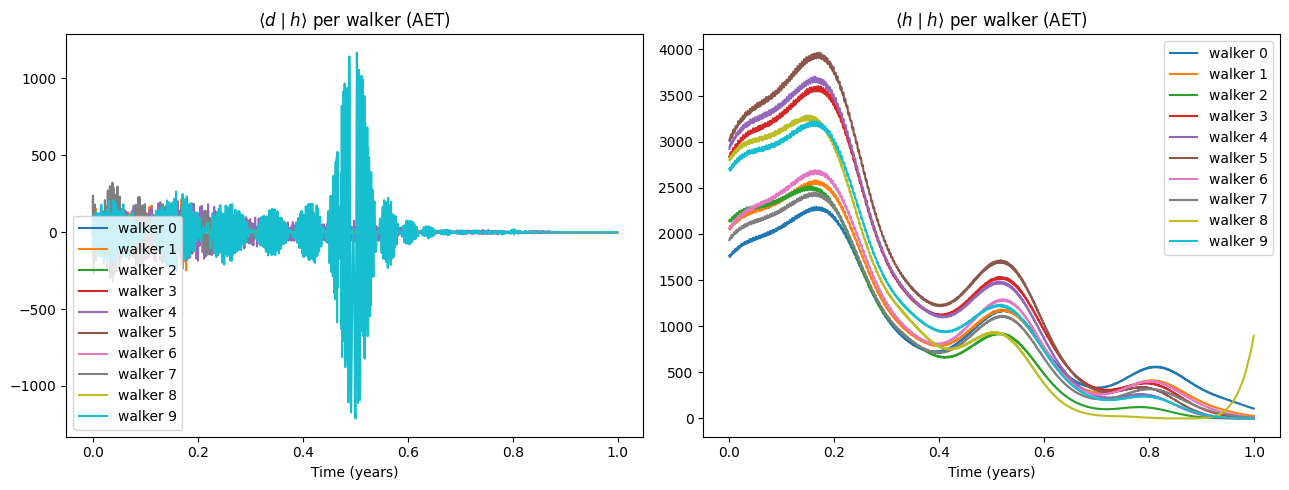

In [36]:
years = gf_generator.t_tranche / (365.25 * 24 * 3600)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
for w in range(10):
    axes[0].plot(years, np.real(stat_gf[w, :, 0]), label=f"walker {w}")
    axes[1].plot(years, np.real(stat_gf[w, :, 1]), label=f"walker {w}")
axes[0].set_title(r"$\langle d \mid h \rangle$ per walker (AET)")
axes[1].set_title(r"$\langle h \mid h \rangle$ per walker (AET)")
for ax in axes:
    ax.set_xlabel("Time (years)")
    ax.legend()
plt.tight_layout()
plt.show()

A single scalar summary per walker (e.g. for a likelihood) is obtained by summing the per-segment inner products over time. The coherent, whole-observation matched-filter SNR of walker `w` is $\langle d\mid h\rangle / \sqrt{\langle h\mid h\rangle}$, summed over segments, (you can follow the same idea to compute the liklelihood, appropriately combining the two quantities):

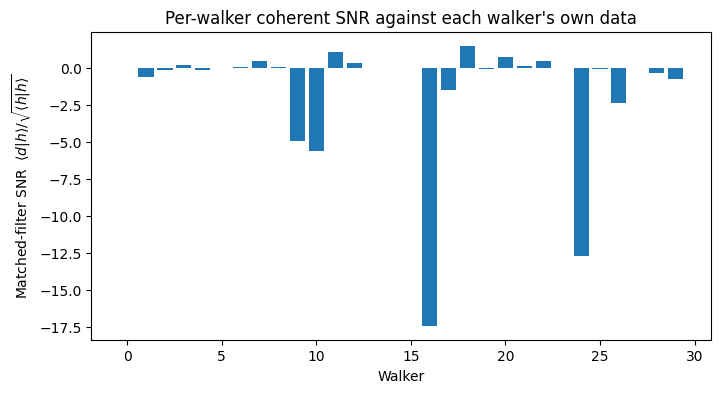

In [37]:
d_h = stat_gf[:, :, 0].sum(axis=1)  # sum over time segments -> (nwalkers,)
h_h = stat_gf[:, :, 1].sum(axis=1)

snr = np.real(d_h) / np.sqrt(np.real(h_h))

plt.figure(figsize=(8, 4))
plt.bar(np.arange(nwalkers), snr)
plt.xlabel("Walker")
plt.ylabel(r"Matched-filter SNR  $\langle d|h\rangle/\sqrt{\langle h|h\rangle}$")
plt.title("Per-walker coherent SNR against each walker's own data")
plt.show()

## Passing per-walker data at call time

The per-walker `channels`/`psds` can also be supplied at call time instead of (or overriding) the ones stored at construction. This is handy in the global fit context where each walker's residual data changes from iteration to iteration. The shapes are the same: `(nwalkers, nT, nF, n_channels)`.

In [39]:
stat_gf_calltime = gf_generator(
    walker_pars,
    parameters_response=walker_response,
    channels=channels_gf,  # (nwalkers, nT, nF, n_channels)
    psds=psds_gf,
    compute_statistic=True,
)

# Identical to using the stored arrays, since we passed the same data.
print("matches stored-array result:", np.allclose(stat_gf_calltime, stat_gf))

matches stored-array result: True


## Consistency check against the shared-data path

Because every walker here was given an identical copy of the data and PSD, global-fit mode must reproduce exactly what the ordinary (shared-data) path computes when it evaluates the same batch of parameters against that single dataset. We verify this below.

In [40]:
# Ordinary shared-data path: one (nT, nF, n_channels) data array shared across the batch.
stat_shared = data_generator(
    walker_pars,
    parameters_response=walker_response,
    channels=signal,  # shared (nT, nF, n_channels)
    psds=psd,
    compute_statistic=True,
)

print("max abs difference:", np.max(np.abs(stat_gf - stat_shared)))
print("gf_mode reproduces shared-data result:", np.allclose(stat_gf, stat_shared))

max abs difference: 0.0
gf_mode reproduces shared-data result: True
